In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ieeg.auth import Session
from scipy import signal
import mne
import json
import pandas as pd
import os
import re
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from multiprocessing import Pool
import scipy.stats as stats
import ast

# Import custom functions
import sys, os
code_v3_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/spike_detector/')
sys.path.append(code_v3_path)
from spike_detector import *
from iEEG_helper_functions import *
from spike_morphology_v2 import *

code_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/working_feat_extract_code/functions/')
sys.path.append(code_path)
from ied_fx_v3 import *

import sys, os
code_v2_path = os.path.dirname('../Ei/')
sys.path.append(code_v2_path)
from utils import get_iEEG_data, notch_filter

In [35]:
hup_ei = pd.read_csv('../data/self_run/hfer_HUP_6s.csv')


# mTLE

First let's look at HUP204's first seizure.

This is a classic MTLE seizure.

Onset time: 29755.28 seconds


In [36]:
#Load the seizure.
end_time = 6 #this is in seconds, we will want to make it 200, if we are working with the other dataset.
begin = 1 #how far back we want to go in seconds.


start_time = 29755.28 - begin #in seconds (remove 40 seconds so that we have the target window)
start_usec = start_time * 1e6
stop_time = start_time + end_time #add 60 seconds (so that we are replicating the target window)
stop_usec = stop_time * 1e6

dataset_name = 'HUP204_phaseII' #dataset name that we want to look at

In [37]:
pw_path = '/mnt/leif/littlab/users/aguilac/tools/agu_ieeglogin.bin'
with open(pw_path, 'r') as f:
    session = Session('aguilac', f.read().strip())

dataset = session.open_dataset(dataset_name)
all_channel_labels = np.array(dataset.get_channel_labels())
channel_labels_to_download = all_channel_labels[
    electrode_selection(all_channel_labels)
]
if channel_labels_to_download.size > 0:
    duration_usec = dataset.get_time_series_details(
        channel_labels_to_download[0]
    ).duration
    duration_secs = duration_usec / 1e6

# get iEEG_data
df, fs = get_iEEG_data(
    username='aguilac',
    password_bin_file = pw_path,
    iEEG_filename=dataset_name,
    start_time_usec=start_usec,
    stop_time_usec=stop_usec,
    select_electrodes = channel_labels_to_download,
)

# Apply notch filters at 60 Hz and harmonics
data = notch_filter(df.to_numpy(), fs) # Change to Bandstop or remove the Phase and Amplitude of 60z & Harms

if fs > 500:
    # Downsample
    target_fs = 500  # Target sampling frequency
    fs = int(fs)
    # Calculate the resampling factors
    gcd = np.gcd(fs, target_fs)
    up = target_fs // gcd
    down = fs // gcd
    # Resample each channel using polynomial interpolation
    downsampled_data = signal.resample_poly(data, up, down, axis=0)
    # Convert the downsampled numpy array back to a DataFrame
    df_downsampled = pd.DataFrame(downsampled_data, columns=[decompose_labels(x, 'HUP204') for x in df.columns])
    # New sampling frequency
    fs = target_fs
    data = df_downsampled

# car_data = common_average_montage(data.to_numpy())
# data = pd.DataFrame(car_data, columns=[decompose_labels(x, 'HUP204') for x in df.columns])



In [38]:
#find the specific row in hup_ei for this seizure.

hupID = 'HUP204'
sz_time = start_time + begin
sz_204 = hup_ei[(hup_ei['hupID'] == hupID) & (hup_ei['ictal_start_time'] == sz_time)]


#now fix the DF, so that we can look at the EI/channel
# remove any row that has all 0's for EI# Assuming 'df' is your DataFrame
sz_204['EI'] = sz_204['EI'].apply(lambda x: list(map(float, x.strip('[]').split())))

# Function to convert string representation of list to actual list
def convert_to_list(string_list):
    return ast.literal_eval(string_list)
# Apply the function to the 'name' column
sz_204['name'] = sz_204['name'].apply(convert_to_list)

# Remove rows where 'EI' is a list of all zeros
df_filtered = sz_204[sz_204['EI'].apply(lambda x: not np.all(np.array(x) == 0.0))]

##############
#HERE WE WILL ADD THE NORMALIZATION ACROSS EACH SEIZURE (PER ROW)
def z_score(values):
    mean = sum(values) / len(values)
    std_dev = (sum((x - mean) ** 2 for x in values) / len(values)) ** 0.5
    z_scores = [(x - mean) / std_dev for x in values]
    return z_scores
    
# df_filtered['EI'] = df_filtered['EI'].apply(z_score)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

def scale_list(lst):
    scaler = MinMaxScaler()
    return scaler.fit_transform(np.array(lst).reshape(-1, 1)).flatten().tolist()

# df_filtered['EI'] = df_filtered['EI'].apply(scale_list)

def enhanced_normalize(lst, power=5):
    arr = np.array(lst)
    mean = np.mean(arr)
    std = np.std(arr)
    
    # Compute z-scores
    z_scores = (arr - mean) / std
    
    # Shift to ensure all values are positive
    min_z = z_scores.min()
    shifted_z = z_scores - min_z
    
    # Scale to [0, 1] range
    max_shifted_z = shifted_z.max()
    normalized = shifted_z / max_shifted_z
    
    # Apply exponential scaling
    enhanced = np.power(normalized, power)
    
    # Re-normalize to [0, 1] range
    enhanced_normalized = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min())
    
    return enhanced_normalized.tolist()

df_filtered['EI'] = df_filtered['EI'].apply(enhanced_normalize)
##############

# Explode the EI and name columns to unnest the lists
df_exploded = df_filtered.explode(['EI', 'name']).drop(columns = ['removed_channels'])

# Reset index if needed
df_exploded = df_exploded.reset_index(drop=True)

df_exploded['name'] = df_exploded['name'].str.replace("'", "", regex=False)

grouped = df_exploded.rename(columns={
    'hupID': 'pt_id',
    'name': 'channel_label',
    'EI': 'EI'  # EI remains the same, but included for clarity
})

grouped['channel_label'] = grouped.apply(
    lambda row: decompose_labels(row['channel_label'], row['pt_id']),
    axis=1
)

chs_tokeep = ['RA','LA','RDA','LDA','LH','RH','LDH','RDH','DA','DH','DHA','LB','LDB','LC','LDC','RB','RDB','RC','RDC']

#if channel_label contains any of the strings in chs_tokeep, keep it
all_spikes = grouped[grouped['channel_label'].str.contains('|'.join(chs_tokeep))].reset_index(drop=True)

all_spikes = all_spikes[~all_spikes['channel_label'].str.contains('T|F|P|RCC|RCA|RAD|LAD|LHD|RHD|LDAH|RDAH|RCB|Z')].reset_index(drop=True)

In [39]:
from scipy import signal

#lets plot the seizure for the channels we want
channels_to_keep = all_spikes['channel_label'].unique().tolist()

b, a = signal.butter(4, [70, 140], 'bandpass', fs=fs)
filt_data = signal.filtfilt(b, a, data)
cleaned_data = pd.DataFrame(filt_data, columns=data.columns)

filtered_data = data[channels_to_keep]

#Lets sort this properly to get a sample seizure clip
la_columns = [col for col in filtered_data.columns if col.startswith('LB')]
sorted_la_columns = ['LA12', 'LA11','LA9', 'LA8', 'LA7', 'LA6', 'LA5', 'LA4', 'LA3', 'LA2','LA1']
sorted_lb_columns = ['LB12','LB11','LB9','LB8','LB7','LB6','LB5','LB4','LB3','LB2','LB1']  
lb_data = filtered_data[sorted_lb_columns]
la_data = filtered_data[sorted_la_columns]


In [40]:
la_columns = [col for col in filtered_data.columns if col.startswith('LA')]
print(sorted(la_columns, reverse = True))


['LA9', 'LA8', 'LA7', 'LA6', 'LA5', 'LA4', 'LA3', 'LA2', 'LA12', 'LA11', 'LA1']


In [41]:
# def plot_eeg_channels_with_hfer(data, all_spikes, sampling_rate=500, stop_time=None, title='Seizure Example', 
#                                 sorted_channels = ['LA12','LA11','LA9','LA8','LA7','LA6','LA5','LA4','LA3','LA2','LA1'], type = 'HFER-11s'):
    
#     plt.rcParams['font.family'] = 'Arial'

#     # Create a time array
#     time = np.arange(0, len(data)) / sampling_rate
    
#     # Set up the plot
#     plt.figure(figsize=(6, 6))

#     plt.title(title, fontsize=16)
    
#     # Define channel order
#     sorted_channels=sorted_channels

#     # Calculate offset and scaling factor for better visibility
#     channel_range = {ch: (data[ch].max() - data[ch].min()) for ch in sorted_channels}
#     max_range = max(channel_range.values())
#     scaling_factor = 1.5
#     offset = max_range * scaling_factor * 0.8
    
#     # Extend the x-axis to accommodate HFER values
#     x_extension_factor = 1.2
    
#     # Plot each channel
#     for i, channel in enumerate(sorted_channels):
#         # Center and scale the data for each channel
#         centered_data = data[channel] - data[channel].mean()
#         scaled_data = (centered_data / channel_range[channel]) * (max_range * scaling_factor)
        
#         plt.plot(time, scaled_data + i*offset, linewidth=0.8, alpha=0.8, color = 'k')
        
#         # Add HFER value as text
#         hfer_value = all_spikes[all_spikes['channel_label'] == channel]['EI'].values
#         if len(hfer_value) > 0:
#             hfer_text = f"HFER: {hfer_value[0]:.2f}"
#             plt.text(len(data)/sampling_rate + 1 , i*offset, hfer_text, 
#                      verticalalignment='center', horizontalalignment='left', fontsize=16,
#                      color = 'r')
    
#     # Add vertical line for seizure onset
#     sz_onset = 1
#     plt.axvline(x=sz_onset, color='k', linestyle='--', label='Seizure Onset')

#     # Add colored bar for 250ms after seizure onset
#     # plt.axvspan(sz_onset, sz_onset + 0.25, facecolor='red', alpha=0.2, label='First 250ms of Seizure')
    
#     # Set y-ticks and labels to channel names
#     plt.yticks(np.arange(len(sorted_channels)) * offset, sorted_channels)
    
#     plt.xlabel('Time (seconds)')
#     plt.ylabel('Channels')
    
#     # Remove top and right spines
#     plt.gca().spines['top'].set_visible(False)
#     plt.gca().spines['right'].set_visible(False)
    
#     # Add minor gridlines for better time reference
#     plt.grid(True, which='both', axis='x', linestyle=':', alpha=0.4)
    
#     plt.legend()
#     plt.tight_layout()

#     plt.savefig(f'../figures/{type}-mtle_sz.pdf', dpi = 500)
#     plt.show()

# plot_eeg_channels_with_hfer(lb_data, all_spikes, stop_time=None, title = 'mTLE Seizure Example', 
#                             sorted_channels = sorted_lb_columns, type = 'HFER-6s')

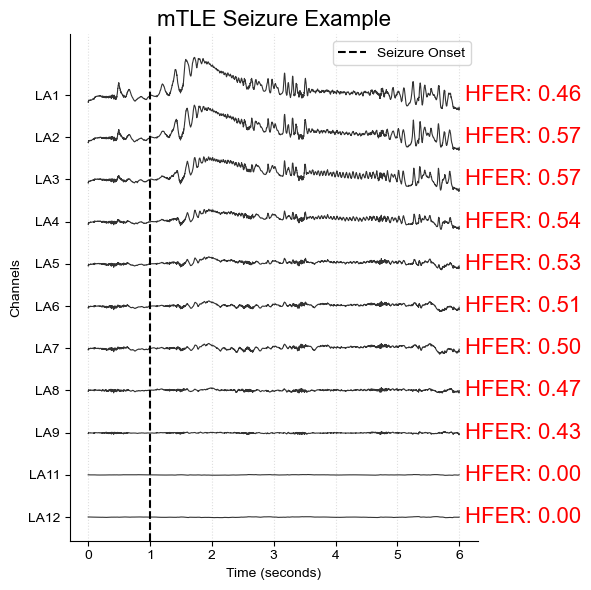

In [42]:
def plot_eeg_channels_with_hfer(data, all_spikes, sampling_rate=500, stop_time=None, title='Seizure Example', 
                                sorted_channels=['LA12','LA11','LA9','LA8','LA7','LA6','LA5','LA4','LA3','LA2','LA1'], type='HFER-11s'):
    
    plt.rcParams['font.family'] = 'Arial'

    # Create a time array
    time = np.arange(0, len(data)) / sampling_rate
    
    # Set up the plot
    plt.figure(figsize=(6, 6))

    plt.title(title, fontsize=16)
    
    # Calculate global min and max for consistent scaling
    global_min = min([data[ch].min() for ch in sorted_channels])
    global_max = max([data[ch].max() for ch in sorted_channels])
    global_range = global_max - global_min

    # Calculate offset for channel separation (reduced for closer channels)
    offset = global_range * 0.8  # Adjust this factor to control channel separation
    
    # Plot each channel
    for i, channel in enumerate(sorted_channels):
        # Use the original data without centering or scaling
        plt.plot(time, data[channel] + i*offset, linewidth=0.8, alpha=0.8, color='k')
        
        # Add HFER value as text
        hfer_value = all_spikes[all_spikes['channel_label'] == channel]['EI'].values
        if len(hfer_value) > 0:
            hfer_text = f"HFER: {hfer_value[0]:.2f}"
            plt.text(len(data)/sampling_rate +0.1, i*offset, hfer_text, 
                     verticalalignment='center', horizontalalignment='left', fontsize=16,
                     color = 'r')
    
    # Add vertical line for seizure onset
    sz_onset = 1
    plt.axvline(x=sz_onset, color='k', linestyle='--', label='Seizure Onset')
    
    # Set y-ticks and labels to channel names
    plt.yticks(np.arange(len(sorted_channels)) * offset, sorted_channels)
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Channels')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add minor gridlines for better time reference
    plt.grid(True, which='both', axis='x', linestyle=':', alpha=0.4)
    
    plt.legend()
    plt.tight_layout()

    plt.savefig(f'../figures/{type}-mtle_sz.pdf', dpi=500)
    plt.show()

# Example usage:
plot_eeg_channels_with_hfer(la_data, all_spikes, stop_time=None, title='mTLE Seizure Example', 
                            sorted_channels=sorted_la_columns, type='HFER-6s')

# TNC

In [43]:
#THINGS WE WANT TO SET
start_time = 418735.801 - begin
start_usec = start_time * 1e6
stop_time = start_time + end_time #add 60 seconds (so that we are replicating the target window)
stop_usec = stop_time * 1e6

hupID = 'HUP215'
dataset_name = 'HUP215_phaseII_D03' 
#'HUP215_phaseII_D03' #dataset name that we want to look at

In [44]:
pw_path = '/mnt/leif/littlab/users/aguilac/tools/agu_ieeglogin.bin'
with open(pw_path, 'r') as f:
    session = Session('aguilac', f.read().strip())

dataset = session.open_dataset(dataset_name)
all_channel_labels = np.array(dataset.get_channel_labels())
channel_labels_to_download = all_channel_labels[
    electrode_selection(all_channel_labels)
]
if channel_labels_to_download.size > 0:
    duration_usec = dataset.get_time_series_details(
        channel_labels_to_download[0]
    ).duration
    duration_secs = duration_usec / 1e6

# get iEEG_data
df, fs = get_iEEG_data(
    username='aguilac',
    password_bin_file = pw_path,
    iEEG_filename=dataset_name,
    start_time_usec=start_usec,
    stop_time_usec=stop_usec,
    select_electrodes = channel_labels_to_download,
)

# Apply notch filters at 60 Hz and harmonics
data = notch_filter(df.to_numpy(), fs) # Change to Bandstop or remove the Phase and Amplitude of 60z & Harms

if fs > 500:
    # Downsample
    target_fs = 500  # Target sampling frequency
    fs = int(fs)
    # Calculate the resampling factors
    gcd = np.gcd(fs, target_fs)
    up = target_fs // gcd
    down = fs // gcd
    # Resample each channel using polynomial interpolation
    downsampled_data = signal.resample_poly(data, up, down, axis=0)
    # Convert the downsampled numpy array back to a DataFrame
    df_downsampled = pd.DataFrame(downsampled_data, columns=[decompose_labels(x, 'HUP215') for x in df.columns])
    # New sampling frequency
    fs = target_fs
    data = df_downsampled

car_data = common_average_montage(data.to_numpy())
data = pd.DataFrame(car_data, columns=[decompose_labels(x, 'HUP215') for x in df.columns])


In [45]:
#find the specific row in hup_ei for this seizure.
sz_time = start_time + begin
sz_204 = hup_ei[(hup_ei['hupID'] == hupID) & (hup_ei['ictal_start_time'] == sz_time)]
sz_204 = sz_204.drop(sz_204.index[-1])

#now fix the DF, so that we can look at the EI/channel
# remove any row that has all 0's for EI# Assuming 'df' is your DataFrame
sz_204['EI'] = sz_204['EI'].apply(lambda x: list(map(float, x.strip('[]').split())))

# Function to convert string representation of list to actual list
def convert_to_list(string_list):
    return ast.literal_eval(string_list)
# Apply the function to the 'name' column
sz_204['name'] = sz_204['name'].apply(convert_to_list)

# Remove rows where 'EI' is a list of all zeros
df_filtered = sz_204[sz_204['EI'].apply(lambda x: not np.all(np.array(x) == 0.0))]

##############
#HERE WE WILL ADD THE NORMALIZATION ACROSS EACH SEIZURE (PER ROW)
def z_score(values):
    mean = sum(values) / len(values)
    std_dev = (sum((x - mean) ** 2 for x in values) / len(values)) ** 0.5
    z_scores = [(x - mean) / std_dev for x in values]
    return z_scores

# df_filtered['EI'] = df_filtered['EI'].apply(z_score)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

def scale_list(lst):
    scaler = MinMaxScaler()
    return scaler.fit_transform(np.array(lst).reshape(-1, 1)).flatten().tolist()

# df_filtered['EI'] = df_filtered['EI'].apply(scale_list)

def enhanced_normalize(lst, power=5):
    arr = np.array(lst)
    mean = np.mean(arr)
    std = np.std(arr)
    
    # Compute z-scores
    z_scores = (arr - mean) / std
    
    # Shift to ensure all values are positive
    min_z = z_scores.min()
    shifted_z = z_scores - min_z
    
    # Scale to [0, 1] range
    max_shifted_z = shifted_z.max()
    normalized = shifted_z / max_shifted_z
    
    # Apply exponential scaling
    enhanced = np.power(normalized, power)
    
    # Re-normalize to [0, 1] range
    enhanced_normalized = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min())
    
    return enhanced_normalized.tolist()

df_filtered['EI'] = df_filtered['EI'].apply(enhanced_normalize)
##############

# Explode the EI and name columns to unnest the lists
df_exploded = df_filtered.explode(['EI', 'name']).drop(columns = ['removed_channels'])

# Reset index if needed
df_exploded = df_exploded.reset_index(drop=True)

df_exploded['name'] = df_exploded['name'].str.replace("'", "", regex=False)

grouped = df_exploded.rename(columns={
    'hupID': 'pt_id',
    'name': 'channel_label',
    'EI': 'EI'  # EI remains the same, but included for clarity
})

grouped['channel_label'] = grouped.apply(
    lambda row: decompose_labels(row['channel_label'], row['pt_id']),
    axis=1
)

chs_tokeep = ['RA','LA','RDA','LDA','LH','RH','LDH','RDH','DA','DH','DHA','LB','LDB','LC','LDC','RB','RDB','RC','RDC']

#if channel_label contains any of the strings in chs_tokeep, keep it
all_spikes = grouped[grouped['channel_label'].str.contains('|'.join(chs_tokeep))].reset_index(drop=True)

all_spikes = all_spikes[~all_spikes['channel_label'].str.contains('T|F|P|RCC|RCA|RAD|LAD|LHD|RHD|LDAH|RDAH|RCB|Z')].reset_index(drop=True)

In [46]:
from scipy import signal
#lets plot the seizure for the channels we want
channels_to_keep = all_spikes['channel_label'].unique().tolist()

# b, a = signal.butter(4, [70, 140], 'bandpass', fs=fs)
# filt_data = signal.filtfilt(b, a, data)
# cleaned_data = pd.DataFrame(filt_data, columns=data.columns)

filtered_data = data[channels_to_keep]

#Lets sort this properly to get a sample seizure clip
la_columns = [col for col in filtered_data.columns if col.startswith('LA')]
lb_columns = [col for col in filtered_data.columns if col.startswith('LB')]
lc_columns = [col for col in filtered_data.columns if col.startswith('LC')]

# sorted_la_columns = ['LA1','LA2','LA3','LA4','LA5','LA6','LA7','LA8','LA9','LA11','LA12']
# sorted_lb_columns = ['LB1','LB2','LB3','LB4','LB5','LB6','LB7','LB8','LB9','LB11','LB12']
la_data = filtered_data[la_columns]
lb_data = filtered_data[lb_columns]
lc_data = filtered_data[lc_columns]

In [47]:
print(sorted(lb_columns, reverse = True))
print(len(lb_columns))
print(sorted(la_columns, reverse = True))
print(len(la_columns))
print(sorted(lc_columns, reverse = True))
print(len(lc_columns))

['LB9', 'LB8', 'LB7', 'LB5', 'LB4', 'LB3', 'LB2', 'LB12', 'LB11', 'LB10', 'LB1']
11
['LA9', 'LA8', 'LA5', 'LA4', 'LA3', 'LA2', 'LA12', 'LA11', 'LA1']
9
['LC8', 'LC7', 'LC6', 'LC5', 'LC4', 'LC3', 'LC2', 'LC1']
8


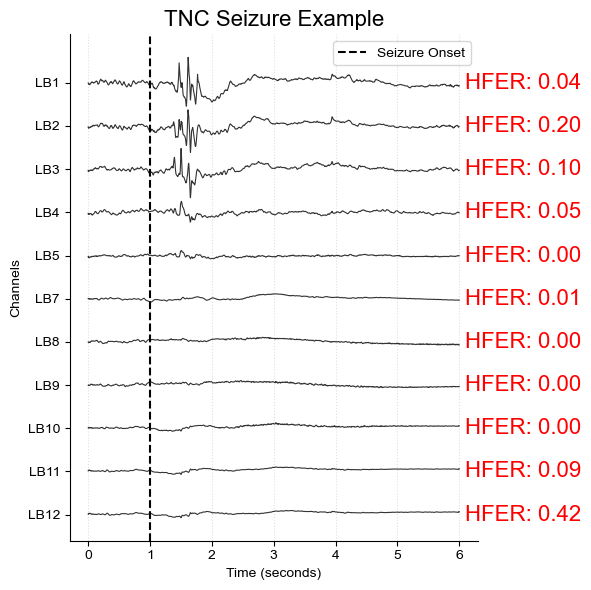

In [51]:
def plot_eeg_channels_with_hfer(data, all_spikes, sampling_rate=500, stop_time=None, title='Seizure Example', 
                                sorted_channels = ['LA12','LA11','LA9','LA8','LA7','LA6','LA5','LA4','LA3','LA2','LA1'], type = "HFER-11s"):
    
    plt.rcParams['font.family'] = 'Arial'

    # Create a time array
    time = np.arange(0, len(data)) / sampling_rate
    
    # Set up the plot
    plt.figure(figsize=(6, 6))

    plt.title(title, fontsize=16)
    
    # Calculate global min and max for consistent scaling
    global_min = min([data[ch].min() for ch in sorted_channels])
    global_max = max([data[ch].max() for ch in sorted_channels])
    global_range = global_max - global_min

    # Calculate offset for channel separation (reduced for closer channels)
    offset = global_range * 0.8  # Adjust this factor to control channel separation
    
    # Plot each channel
    for i, channel in enumerate(sorted_channels):
        # Use the original data without centering or scaling
        plt.plot(time, data[channel] + i*offset, linewidth=0.8, alpha=0.8, color='k')
        
        # Add HFER value as text
        hfer_value = all_spikes[all_spikes['channel_label'] == channel]['EI'].values
        if len(hfer_value) > 0:
            hfer_text = f"HFER: {hfer_value[0]:.2f}"
            plt.text(len(data)/sampling_rate +0.1, i*offset, hfer_text, 
                     verticalalignment='center', horizontalalignment='left', fontsize=16,
                     color = 'r')
    
    # Add vertical line for seizure onset
    sz_onset = 1
    plt.axvline(x=sz_onset, color='k', linestyle='--', label='Seizure Onset')
    
    # Set y-ticks and labels to channel names
    plt.yticks(np.arange(len(sorted_channels)) * offset, sorted_channels)
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Channels')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add minor gridlines for better time reference
    plt.grid(True, which='both', axis='x', linestyle=':', alpha=0.4)
    
    plt.legend()
    plt.tight_layout()

    plt.savefig(f'../figures/{type}-tnc_sz.pdf', dpi=500)
    plt.show()


plot_eeg_channels_with_hfer(lb_data, all_spikes, stop_time=None, title = 'TNC Seizure Example', 
                            sorted_channels = ['LB12','LB11','LB10','LB9', 'LB8', 'LB7', 'LB5', 'LB4', 'LB3', 'LB2','LB1'], type = 'HFER-6s')
                            # sorted_channels=['LC8', 'LC7', 'LC6', 'LC5', 'LC4', 'LC3', 'LC2', 'LC1']